In [1]:
import pandas as pd

# Create a DataFrame with 1 row and 3 columns
data = { 
    "Name": ["Jissy Jayaprakash"],  
    "Questions": ["Model 1, 2, 3, 4, 5"],  
    "Contributions": [
        "Created Model 1 - Naive Bayes model using Count Vectors for Unigram.\n"
        "Model 3 - Naive Bayes model using TF-IDF Vectors for Unigram+Bigram.\n"
        "Model 5 - Naive Bayes model using One-Hot Vectors with Unigram+Bigram.\n"
        "Model 2 - SVM model using TF-IDF Vectors with Unigram+Bigram.\n"
        "Model 4 - SVM model using Count Vectors for Unigram+Bigram."
    ]  
}

# Create DataFrame
df = pd.DataFrame(data)

# Reset index to start from 1
df.index = df.index + 1

# Display the DataFrame with proper formatting
df.style.set_properties(subset=['Contributions'], **{'white-space': 'pre-wrap'})




,Name,Questions,Contributions
1,Jissy Jayaprakash,"Model 1, 2, 3, 4, 5",Created Model 1 - Naive Bayes model using Count Vectors for Unigram. Model 3 - Naive Bayes model using TF-IDF Vectors for Unigram+Bigram. Model 5 - Naive Bayes model using One-Hot Vectors with Unigram+Bigram. Model 2 - SVM model using TF-IDF Vectors with Unigram+Bigram. Model 4 - SVM model using Count Vectors for Unigram+Bigram.


In [2]:
## Step 1: Importing Necessary Libraries
import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_path = r"C:\Users\ASUS\OneDrive\Desktop\Semester 3\NLP\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_review.json"

In [4]:
import random

sample_size = 30000  # Adjust this number based on your memory capacity
data = pd.read_json(data_path, lines=True, chunksize=sample_size)

# Load a single chunk as a sample
sample_data = next(data)
sample_data = sample_data[["text", "stars"]]
print(sample_data.head())


                                                text  stars
0  If you decide to eat here, just be aware it is...      3
1  I've taken a lot of spin classes over the year...      5
2  Family diner. Had the buffet. Eclectic assortm...      3
3  Wow!  Yummy, different,  delicious.   Our favo...      5
4  Cute interior and owner (?) gave us tour of up...      4


In [5]:
# Map star ratings to sentiment labels
def map_sentiment(stars):
    if stars >= 4:
        return "Positive"
    elif stars <= 2:
        return "Negative"
    else:
        return "Neutral"

sample_data['sentiment'] = sample_data['stars'].apply(map_sentiment)

# Check the updated DataFrame
print(sample_data.head())
print(sample_data['sentiment'].value_counts())  # Check distribution of sentiments


                                                text  stars sentiment
0  If you decide to eat here, just be aware it is...      3   Neutral
1  I've taken a lot of spin classes over the year...      5  Positive
2  Family diner. Had the buffet. Eclectic assortm...      3   Neutral
3  Wow!  Yummy, different,  delicious.   Our favo...      5  Positive
4  Cute interior and owner (?) gave us tour of up...      4  Positive
sentiment
Positive    21003
Negative     5589
Neutral      3408
Name: count, dtype: int64


In [6]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK resources if needed
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Define preprocessing function
def preprocess_text(text):
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]
    # Rejoin tokens
    return " ".join(tokens)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
# Apply preprocessing to the text column
sample_data['cleaned_text'] = sample_data['text'].apply(preprocess_text)

# Proceed with splitting
X = sample_data['cleaned_text']  # Use preprocessed text
y = sample_data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)



In [8]:
# Check sizes of the splits
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 21000
Test set size: 9000


# 1. Naive Bayes Model with Count Vectors (Unigram)


Training Model 1: Naive Bayes with Count Vectors (Unigram)


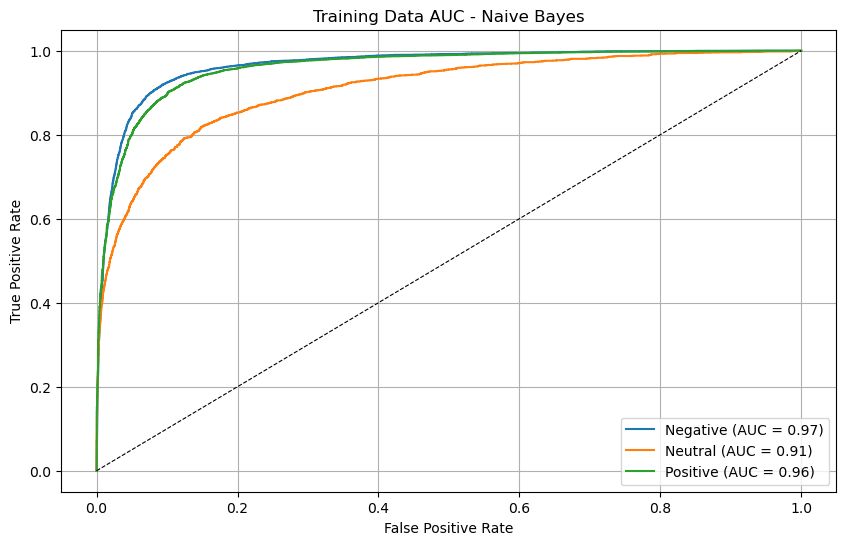

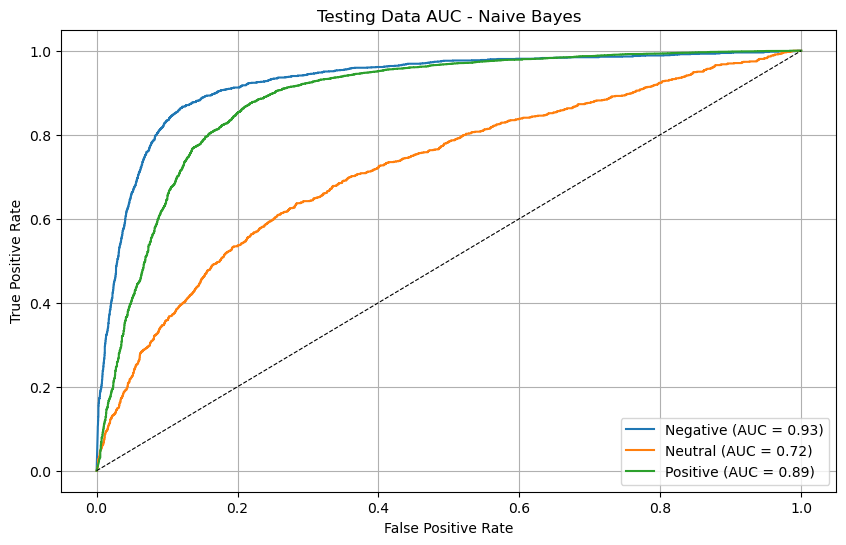


--- Model 1: Naive Bayes with Count Vectors (Unigram) ---
Train Time: 0.11 seconds

Training Data Check:
F1 Score (Positive): 0.9341
F1 Score (Negative): 0.8197
AUC Scores: {'Negative': 0.9653964270960188, 'Neutral': 0.9078262416115783, 'Positive': 0.959982318787225}
Accuracy: 0.8814
Feature Engineering: Count Vectors (Unigram)
Cross Validation Interpretability: Local

Testing Data Check:
F1 Score (Positive): 0.8959
F1 Score (Negative): 0.7255
AUC Scores: {'Negative': 0.9267576665802707, 'Neutral': 0.7196188736245811, 'Positive': 0.8886539119774857}
Accuracy: 0.8133


In [9]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

def plot_auc(y_true, y_proba, classes, title):
    """
    Plot AUC curve for each class.
    """
    plt.figure(figsize=(10, 6))
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
        auc_score = roc_auc_score(y_true[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# Model 1: Naive Bayes with Count Vectors (Unigram)
print("\nTraining Model 1: Naive Bayes with Count Vectors (Unigram)")

# Feature Engineering
count_vect = CountVectorizer(ngram_range=(1, 1))
X_train_cv = count_vect.fit_transform(X_train)
X_test_cv = count_vect.transform(X_test)

# Training the model
start_time = time.time()
nb_model_cv = MultinomialNB()
nb_model_cv.fit(X_train_cv, y_train)
train_time = time.time() - start_time

# Training Data Predictions
y_train_pred = nb_model_cv.predict(X_train_cv)
y_train_pred_proba = nb_model_cv.predict_proba(X_train_cv)

# Testing Data Predictions
y_test_pred = nb_model_cv.predict(X_test_cv)
y_test_pred_proba = nb_model_cv.predict_proba(X_test_cv)

# Binarize labels for AUC calculation
y_train_binarized = label_binarize(y_train, classes=nb_model_cv.classes_)
y_test_binarized = label_binarize(y_test, classes=nb_model_cv.classes_)

# Plot AUC for training data
plot_auc(y_train_binarized, y_train_pred_proba, nb_model_cv.classes_, title="Training Data AUC - Naive Bayes")

# Plot AUC for testing data
plot_auc(y_test_binarized, y_test_pred_proba, nb_model_cv.classes_, title="Testing Data AUC - Naive Bayes")

# Training Data Metrics
train_report = classification_report(y_train, y_train_pred, output_dict=True)
f1_train_positive = train_report['Positive']['f1-score']
f1_train_negative = train_report['Negative']['f1-score']
train_accuracy = accuracy_score(y_train, y_train_pred)

# Training AUC
train_auc_scores = {
    label: roc_auc_score(y_train_binarized[:, i], y_train_pred_proba[:, i])
    for i, label in enumerate(nb_model_cv.classes_)
}

# Testing Data Metrics
test_report = classification_report(y_test, y_test_pred, output_dict=True)
f1_test_positive = test_report['Positive']['f1-score']
f1_test_negative = test_report['Negative']['f1-score']
test_accuracy = accuracy_score(y_test, y_test_pred)

# Testing AUC
test_auc_scores = {
    label: roc_auc_score(y_test_binarized[:, i], y_test_pred_proba[:, i])
    for i, label in enumerate(nb_model_cv.classes_)
}

# Output Results
print("\n--- Model 1: Naive Bayes with Count Vectors (Unigram) ---")
print(f"Train Time: {train_time:.2f} seconds")

print("\nTraining Data Check:")
print(f"F1 Score (Positive): {f1_train_positive:.4f}")
print(f"F1 Score (Negative): {f1_train_negative:.4f}")
print(f"AUC Scores: {train_auc_scores}")
print(f"Accuracy: {train_accuracy:.4f}")
print("Feature Engineering: Count Vectors (Unigram)")
print("Cross Validation Interpretability: Local")

print("\nTesting Data Check:")
print(f"F1 Score (Positive): {f1_test_positive:.4f}")
print(f"F1 Score (Negative): {f1_test_negative:.4f}")
print(f"AUC Scores: {test_auc_scores}")
print(f"Accuracy: {test_accuracy:.4f}")


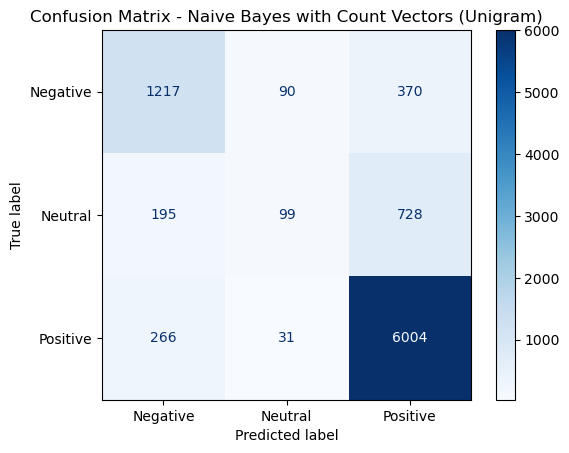


Confusion Matrix:
[[1217   90  370]
 [ 195   99  728]
 [ 266   31 6004]]


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred, labels=nb_model_cv.classes_)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=nb_model_cv.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation="horizontal")
plt.title("Confusion Matrix - Naive Bayes with Count Vectors (Unigram)")
plt.show()

# Print confusion matrix details
print("\nConfusion Matrix:")
print(conf_matrix)

# 3. Naive Bayes model using TF-IDF Vectors for Unigram+Bigram

Resampled class distribution: {'Negative': 14702, 'Neutral': 14702, 'Positive': 14702}

Training Model 3: Naive Bayes with TF-IDF Vectors (Unigram + Bigram)


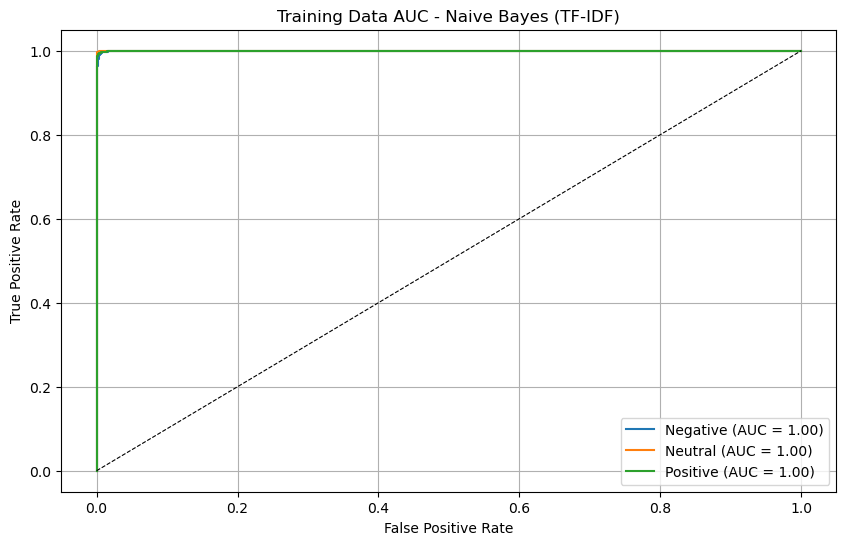

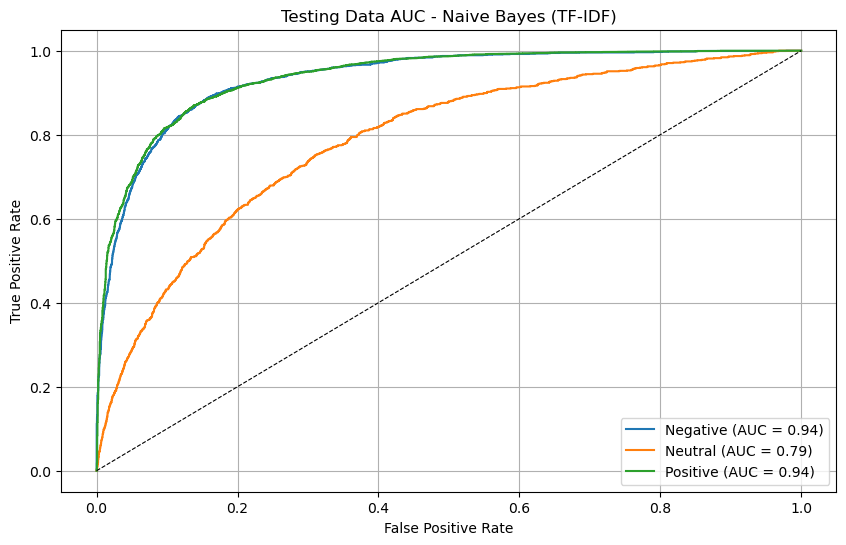


--- Model 3: Naive Bayes with TF-IDF Vectors (Unigram + Bigram) ---
Train Time: 0.63 seconds

Training Data Check:
F1 Score (Positive): 0.9659
F1 Score (Negative): 0.9871
AUC Scores: {'Negative': 0.9997229107962124, 'Neutral': 0.9999676357219167, 'Positive': 0.9998002533476892}
Accuracy: 0.9772
Feature Engineering: TF-IDF Vectors (Unigram + Bigram)
Cross Validation Interpretability: Local

Testing Data Check:
F1 Score (Positive): 0.8286
F1 Score (Negative): 0.7102
AUC Scores: {'Negative': 0.9351504490267674, 'Neutral': 0.786491619075746, 'Positive': 0.9381055919010252}
Accuracy: 0.7260


In [11]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE
import numpy as np

# Plot AUC function (reused from Model 1)
def plot_auc(y_true, y_proba, classes, title):
    """
    Plot AUC curve for each class.
    """
    plt.figure(figsize=(10, 6))
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
        auc_score = roc_auc_score(y_true[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# Feature Engineering
tfidf_vect = TfidfVectorizer(ngram_range=(1, 2))  # Unigram + Bigram
X_train_tfidf = tfidf_vect.fit_transform(X_train)  # Vectorize the text data
X_test_tfidf = tfidf_vect.transform(X_test)  # Apply same transformation on the test data

# Apply SMOTE to oversample the minority class after vectorization
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

# Check the distribution of classes after resampling
print(f"Resampled class distribution: {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

# Model 3: Naive Bayes with TF-IDF Vectors (Unigram + Bigram)
print("\nTraining Model 3: Naive Bayes with TF-IDF Vectors (Unigram + Bigram)")

# Training the model with resampled data
start_time = time.time()
nb_model_tfidf = MultinomialNB()
nb_model_tfidf.fit(X_train_resampled, y_train_resampled)  # Train on resampled data
train_time = time.time() - start_time

# Training Data Predictions
y_train_pred = nb_model_tfidf.predict(X_train_resampled)
y_train_pred_proba = nb_model_tfidf.predict_proba(X_train_resampled)

# Testing Data Predictions
y_test_pred = nb_model_tfidf.predict(X_test_tfidf)
y_test_pred_proba = nb_model_tfidf.predict_proba(X_test_tfidf)

# Binarize labels for AUC calculation
y_train_binarized = label_binarize(y_train_resampled, classes=nb_model_tfidf.classes_)
y_test_binarized = label_binarize(y_test, classes=nb_model_tfidf.classes_)

# Plot AUC for training data
plot_auc(y_train_binarized, y_train_pred_proba, nb_model_tfidf.classes_, title="Training Data AUC - Naive Bayes (TF-IDF)")

# Plot AUC for testing data
plot_auc(y_test_binarized, y_test_pred_proba, nb_model_tfidf.classes_, title="Testing Data AUC - Naive Bayes (TF-IDF)")

# Training Data Metrics
train_report = classification_report(y_train_resampled, y_train_pred, output_dict=True)
f1_train_positive = train_report['Positive']['f1-score']
f1_train_negative = train_report['Negative']['f1-score']
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)

# Training AUC
train_auc_scores = {
    label: roc_auc_score(y_train_binarized[:, i], y_train_pred_proba[:, i])
    for i, label in enumerate(nb_model_tfidf.classes_)
}

# Testing Data Metrics
test_report = classification_report(y_test, y_test_pred, output_dict=True)
f1_test_positive = test_report['Positive']['f1-score']
f1_test_negative = test_report['Negative']['f1-score']
test_accuracy = accuracy_score(y_test, y_test_pred)

# Testing AUC
test_auc_scores = {
    label: roc_auc_score(y_test_binarized[:, i], y_test_pred_proba[:, i])
    for i, label in enumerate(nb_model_tfidf.classes_)
}

# Output Results
print("\n--- Model 3: Naive Bayes with TF-IDF Vectors (Unigram + Bigram) ---")
print(f"Train Time: {train_time:.2f} seconds")

print("\nTraining Data Check:")
print(f"F1 Score (Positive): {f1_train_positive:.4f}")
print(f"F1 Score (Negative): {f1_train_negative:.4f}")
print(f"AUC Scores: {train_auc_scores}")
print(f"Accuracy: {train_accuracy:.4f}")
print("Feature Engineering: TF-IDF Vectors (Unigram + Bigram)")
print("Cross Validation Interpretability: Local")

print("\nTesting Data Check:")
print(f"F1 Score (Positive): {f1_test_positive:.4f}")
print(f"F1 Score (Negative): {f1_test_negative:.4f}")
print(f"AUC Scores: {test_auc_scores}")
print(f"Accuracy: {test_accuracy:.4f}")


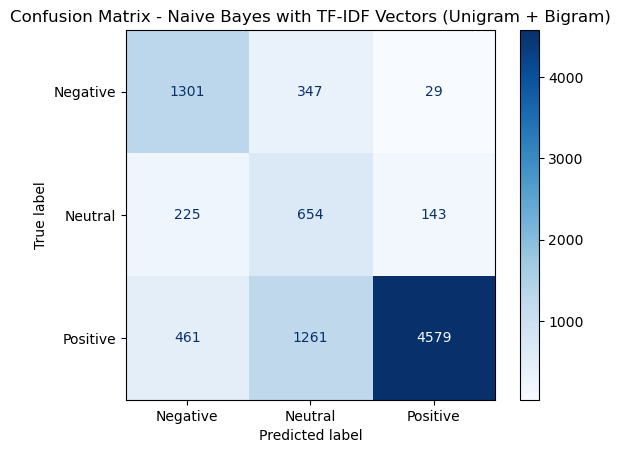


Confusion Matrix:
[[1301  347   29]
 [ 225  654  143]
 [ 461 1261 4579]]


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred, labels=nb_model_tfidf.classes_)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=nb_model_tfidf.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation="horizontal")
plt.title("Confusion Matrix - Naive Bayes with TF-IDF Vectors (Unigram + Bigram)")
plt.show()
# Print confusion matrix details
print("\nConfusion Matrix:")
print(conf_matrix)

# 5. Naive Bayes model using One-Hot Vectors with Unigram+Bigram



Training Model: Naive Bayes with One-Hot Vectors (Unigram + Bigram)


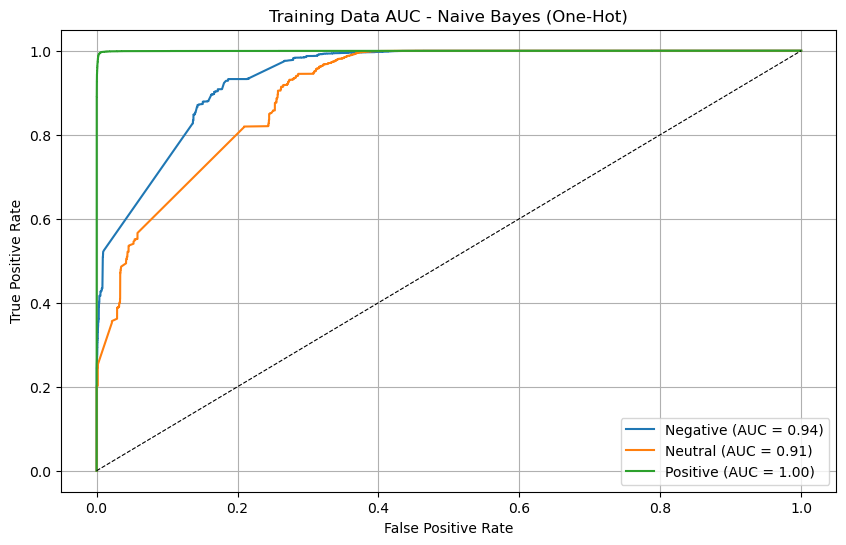

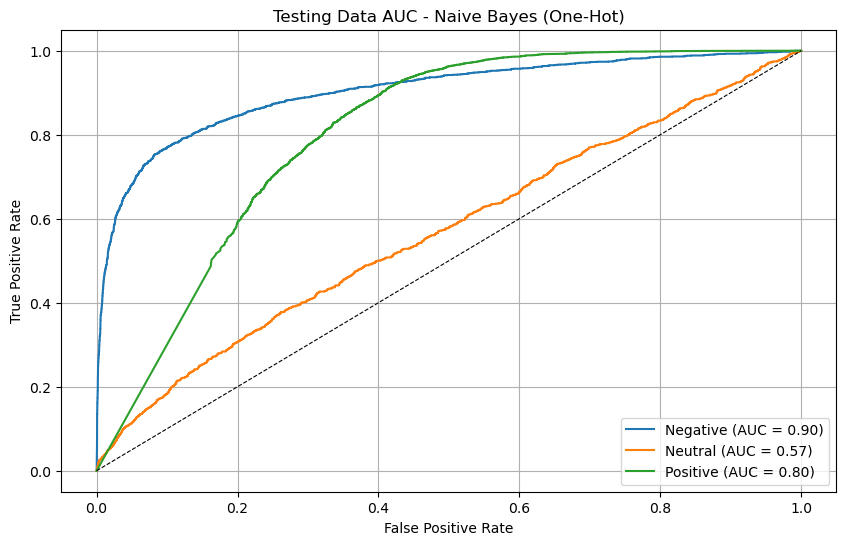


--- Model: Naive Bayes with One-Hot Vectors (Unigram + Bigram) ---
Train Time: 0.58 seconds

Training Data Check:
F1 Score (Positive): 0.8496
F1 Score (Negative): 0.7721
AUC Scores: {'Negative': 0.9419448406940989, 'Neutral': 0.9058320547080151, 'Positive': 0.9994926805146698}
Accuracy: 0.7607
Feature Engineering: One-Hot Vectors (Unigram + Bigram)
Cross Validation Interpretability: Local

Testing Data Check:
F1 Score (Positive): 0.8694
F1 Score (Negative): 0.6152
AUC Scores: {'Negative': 0.9031319217003698, 'Neutral': 0.5691429317119142, 'Positive': 0.8031791445090757}
Accuracy: 0.7842


In [13]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE

# Plot AUC function (reused)
def plot_auc(y_true, y_proba, classes, title):
    """
    Plot AUC curve for each class.
    """
    plt.figure(figsize=(10, 6))
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
        auc_score = roc_auc_score(y_true[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# Model: Naive Bayes with One-Hot Vectors (Unigram + Bigram)
print("\nTraining Model: Naive Bayes with One-Hot Vectors (Unigram + Bigram)")

# Feature Engineering
one_hot_vect = CountVectorizer(ngram_range=(1, 2), binary=True)  # One-hot encoding with Unigram + Bigram
X_train_one_hot = one_hot_vect.fit_transform(X_train)
X_test_one_hot = one_hot_vect.transform(X_test)

# Apply SMOTE for handling class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_one_hot, y_train)

# Training the model on resampled data
start_time = time.time()
nb_model_one_hot = MultinomialNB()
nb_model_one_hot.fit(X_train_resampled, y_train_resampled)
train_time = time.time() - start_time

# Training Data Predictions
y_train_pred = nb_model_one_hot.predict(X_train_resampled)
y_train_pred_proba = nb_model_one_hot.predict_proba(X_train_resampled)

# Testing Data Predictions
y_test_pred = nb_model_one_hot.predict(X_test_one_hot)
y_test_pred_proba = nb_model_one_hot.predict_proba(X_test_one_hot)

# Binarize labels for AUC calculation (on resampled training data)
y_train_binarized = label_binarize(y_train_resampled, classes=nb_model_one_hot.classes_)
y_test_binarized = label_binarize(y_test, classes=nb_model_one_hot.classes_)

# Plot AUC for training data
plot_auc(y_train_binarized, y_train_pred_proba, nb_model_one_hot.classes_, title="Training Data AUC - Naive Bayes (One-Hot)")

# Plot AUC for testing data
plot_auc(y_test_binarized, y_test_pred_proba, nb_model_one_hot.classes_, title="Testing Data AUC - Naive Bayes (One-Hot)")

# Training Data Metrics
train_report = classification_report(y_train_resampled, y_train_pred, output_dict=True)
f1_train_positive = train_report['Positive']['f1-score']
f1_train_negative = train_report['Negative']['f1-score']
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)

# Training AUC
train_auc_scores = {
    label: roc_auc_score(y_train_binarized[:, i], y_train_pred_proba[:, i])
    for i, label in enumerate(nb_model_one_hot.classes_)
}

# Testing Data Metrics
test_report = classification_report(y_test, y_test_pred, output_dict=True)
f1_test_positive = test_report['Positive']['f1-score']
f1_test_negative = test_report['Negative']['f1-score']
test_accuracy = accuracy_score(y_test, y_test_pred)

# Testing AUC
test_auc_scores = {
    label: roc_auc_score(y_test_binarized[:, i], y_test_pred_proba[:, i])
    for i, label in enumerate(nb_model_one_hot.classes_)
}

# Output Results
print("\n--- Model: Naive Bayes with One-Hot Vectors (Unigram + Bigram) ---")
print(f"Train Time: {train_time:.2f} seconds")

print("\nTraining Data Check:")
print(f"F1 Score (Positive): {f1_train_positive:.4f}")
print(f"F1 Score (Negative): {f1_train_negative:.4f}")
print(f"AUC Scores: {train_auc_scores}")
print(f"Accuracy: {train_accuracy:.4f}")
print("Feature Engineering: One-Hot Vectors (Unigram + Bigram)")
print("Cross Validation Interpretability: Local")

print("\nTesting Data Check:")
print(f"F1 Score (Positive): {f1_test_positive:.4f}")
print(f"F1 Score (Negative): {f1_test_negative:.4f}")
print(f"AUC Scores: {test_auc_scores}")
print(f"Accuracy: {test_accuracy:.4f}")


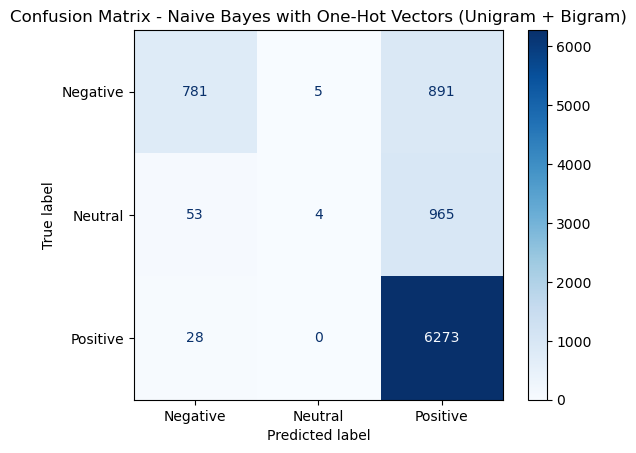


Confusion Matrix:
[[ 781    5  891]
 [  53    4  965]
 [  28    0 6273]]


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming your model and predictions are already done, you can use the following code to generate the confusion matrix:

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred, labels=nb_model_one_hot.classes_)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=nb_model_one_hot.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation="horizontal")
plt.title("Confusion Matrix - Naive Bayes with One-Hot Vectors (Unigram + Bigram)")
plt.show()

# Print confusion matrix details
print("\nConfusion Matrix:")
print(conf_matrix)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best Parameters: {'C': 10}


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.77      0.78      1677
     Neutral       0.45      0.28      0.34      1022
    Positive       0.89      0.95      0.92      6301

    accuracy                           0.84      9000
   macro avg       0.71      0.67      0.68      9000
weighted avg       0.82      0.84      0.83      9000


Confusion Matrix:
[[1299  154  224]
 [ 219  284  519]
 [ 140  200 5961]]

ROC-AUC Score: 0.8156586046762015


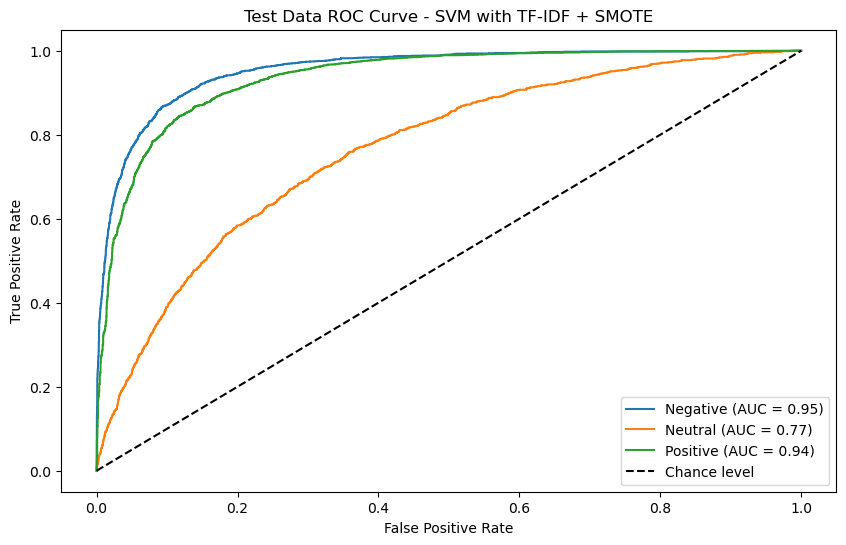

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd

# Downsample Dataset for Tuning (Example with 20,000 samples for tuning)
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, test_size=0.8, random_state=42)

# Feature Engineering with TF-IDF Vectors (Unigram + Bigram)
tfidf_vect = TfidfVectorizer(ngram_range=(1, 2))
X_sample_tfidf = tfidf_vect.fit_transform(X_sample)
X_test_tfidf = tfidf_vect.transform(X_test)

# Apply SMOTE (Oversampling) to handle class imbalance in the training data
smote = SMOTE(random_state=42)
X_sample_tfidf_res, y_sample_res = smote.fit_resample(X_sample_tfidf, y_sample)

# Define Model
svc = LinearSVC()

# Hyperparameter Tuning with GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 10]}  # Regularization parameter
grid_search = GridSearchCV(
    svc,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,  # Use all available cores
    verbose=1   # Show progress
)

# Fit on Oversampled Dataset (Resampled with SMOTE)
grid_search.fit(X_sample_tfidf_res, y_sample_res)

# Best Model from Grid Search
best_svc = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Train Best Model on Full Dataset
X_train_tfidf = tfidf_vect.transform(X_train)  # Fit-transform full training data
best_svc.fit(X_train_tfidf, y_train)

# Predictions on Test Data
y_pred = best_svc.predict(X_test_tfidf)

# Evaluation Metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# AUC (for a multiclass scenario, compute AUC using One-vs-Rest)
roc_auc = roc_auc_score(
    pd.get_dummies(y_test), 
    pd.get_dummies(y_pred), 
    average="weighted", 
    multi_class="ovr"
)
print("\nROC-AUC Score:", roc_auc)

# Plot ROC Curve for each class
def plot_roc_curve(y_true, y_pred_prob, classes, title="ROC Curve"):
    """
    This function plots the ROC curve for each class.
    """
    plt.figure(figsize=(10, 6))
    
    # Binarize the labels for multi-class AUC
    y_true_bin = label_binarize(y_true, classes=classes)
    
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        auc_score = roc_auc_score(y_true_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")
    
    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Get predicted probabilities for the test set (LinearSVC does not directly support predict_proba)
# Use decision function (output is the distance from the hyperplane)
y_pred_prob = best_svc.decision_function(X_test_tfidf)

# Get class labels (if they are not available, use the classes in the order the model was trained)
classes = best_svc.classes_

# Plot ROC for Test Data
plot_roc_curve(y_test, y_pred_prob, classes, title="Test Data ROC Curve - SVM with TF-IDF + SMOTE")



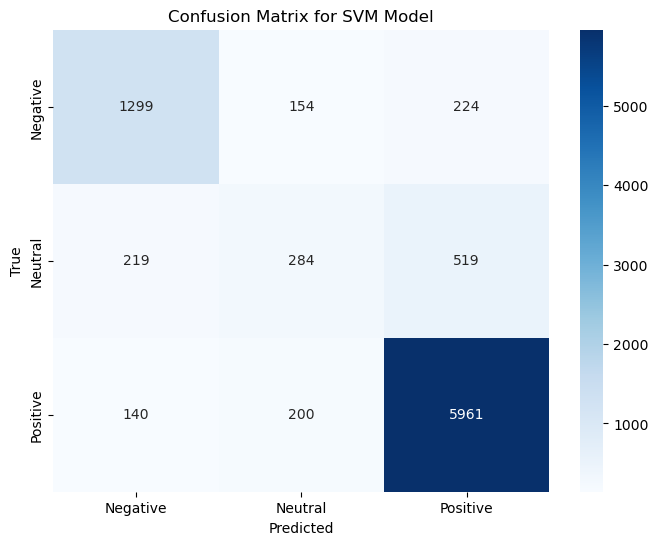

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'y_test' are the true labels and 'y_pred' are the predictions made by your model
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix with Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for SVM Model')
plt.show()


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.77      0.78      1677
     Neutral       0.48      0.25      0.33      1022
    Positive       0.88      0.96      0.92      6301

    accuracy                           0.84      9000
   macro avg       0.72      0.66      0.68      9000
weighted avg       0.82      0.84      0.83      9000


Confusion Matrix:
[[1291  132  254]
 [ 223  260  539]
 [ 122  155 6024]]


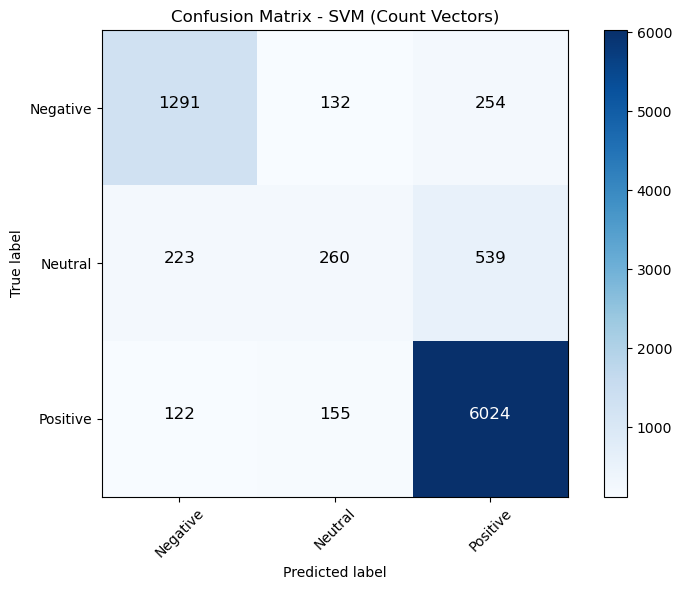


ROC-AUC Score: 0.8115508545651822


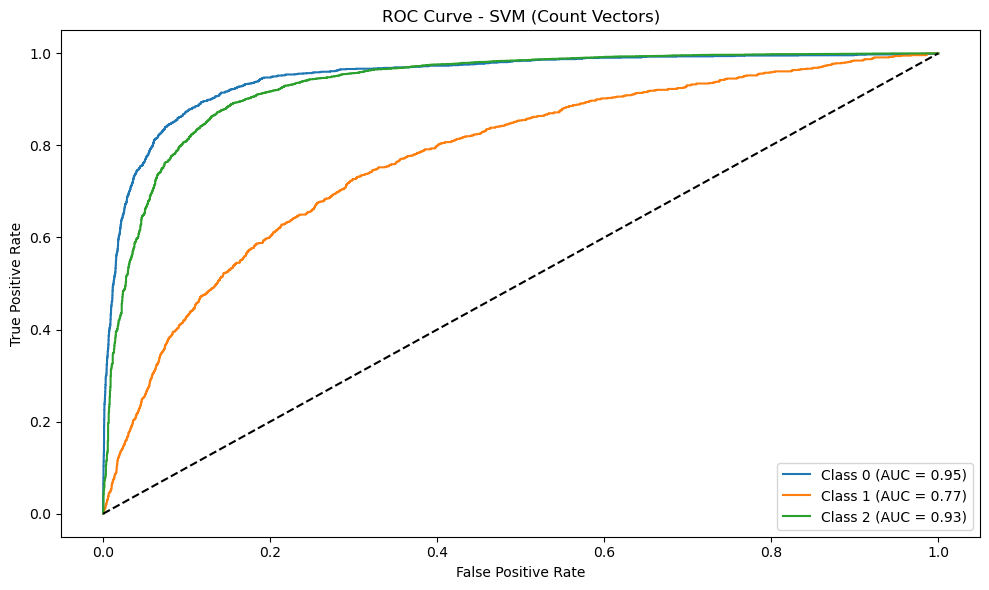

In [17]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize

# Assuming you have X_train, X_test, y_train, and y_test defined

# Feature Engineering with Count Vectors (Unigram + Bigram)
count_vect = CountVectorizer(ngram_range=(1, 2))  # Unigram + Bigram
X_train_cv = count_vect.fit_transform(X_train)
X_test_cv = count_vect.transform(X_test)

# Define and Train the SVM Model
svc = LinearSVC()
svc.fit(X_train_cv, y_train)

# Predictions on Test Data
y_pred = svc.predict(X_test_cv)

# Evaluation: Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM (Count Vectors)")
plt.colorbar()
tick_marks = np.arange(len(conf_matrix))
plt.xticks(tick_marks, np.unique(y_test), rotation=45)
plt.yticks(tick_marks, np.unique(y_test))

# Add labels to the confusion matrix
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j]), fontsize=12,
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# AUC Score for Multiclass (One-vs-Rest)
roc_auc = roc_auc_score(
    pd.get_dummies(y_test), 
    pd.get_dummies(y_pred), 
    average="weighted", 
    multi_class="ovr"
)
print("\nROC-AUC Score:", roc_auc)

# Plotting ROC Curve
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
y_pred_prob = svc.decision_function(X_test_cv)  # Get decision function scores for ROC curve

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc_vals = {}, {}, {}
for i in range(len(np.unique(y_test))):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc_vals[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 6))
for i in range(len(np.unique(y_test))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc_vals[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--')

plt.title('ROC Curve - SVM (Count Vectors)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# 2. SVM model using TF-IDF Vectors with Unigram+Bigram



Fitting 3 folds for each of 4 candidates, totalling 12 fits


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best Parameters: {'C': 10}


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



Classification Report (Test Data):
              precision    recall  f1-score   support

    Negative       0.78      0.77      0.78      1677
     Neutral       0.45      0.28      0.34      1022
    Positive       0.89      0.95      0.92      6301

    accuracy                           0.84      9000
   macro avg       0.71      0.67      0.68      9000
weighted avg       0.82      0.84      0.83      9000


Confusion Matrix (Test Data):
[[1299  154  224]
 [ 219  284  519]
 [ 140  200 5961]]

--- Model: SVM with TF-IDF Vectors (Unigram + Bigram) ---
Train Time: 3.66 seconds

Training Data Check:
F1 Score (Positive): 1.0000
F1 Score (Negative): 1.0000
Accuracy: 1.0000
AUC Scores: {'Negative': 1.0, 'Neutral': 1.0, 'Positive': 1.0}

Testing Data Check:
F1 Score (Positive): 0.9167
F1 Score (Negative): 0.7790
Accuracy: 0.8382
AUC Scores: {'Negative': 0.9546115599058063, 'Neutral': 0.7653900476800438, 'Positive': 0.9367100583727339}


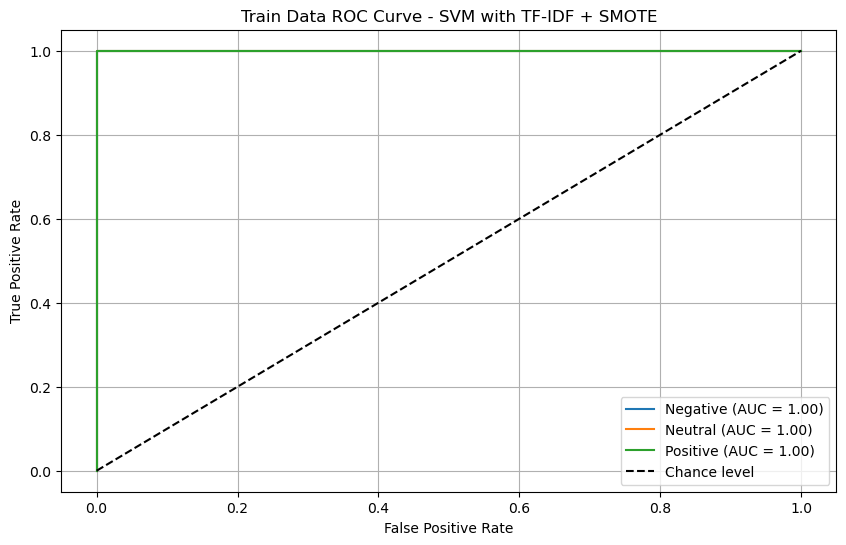

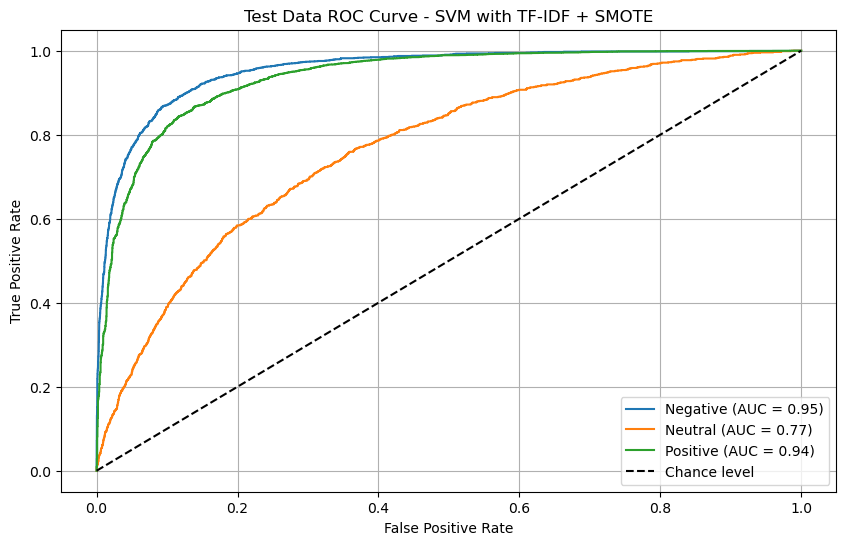

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, accuracy_score
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd
import time

# Downsample Dataset for Tuning (Example with 20,000 samples for tuning)
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, test_size=0.8, random_state=42)

# Feature Engineering with TF-IDF Vectors (Unigram + Bigram)
tfidf_vect = TfidfVectorizer(ngram_range=(1, 2))
X_sample_tfidf = tfidf_vect.fit_transform(X_sample)
X_test_tfidf = tfidf_vect.transform(X_test)

# Apply SMOTE (Oversampling) to handle class imbalance in the training data
smote = SMOTE(random_state=42)
X_sample_tfidf_res, y_sample_res = smote.fit_resample(X_sample_tfidf, y_sample)

# Define Model
svc = LinearSVC()

# Hyperparameter Tuning with GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 10]}  # Regularization parameter
grid_search = GridSearchCV(
    svc,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,  # Use all available cores
    verbose=1   # Show progress
)

# Fit on Oversampled Dataset (Resampled with SMOTE)
grid_search.fit(X_sample_tfidf_res, y_sample_res)

# Best Model from Grid Search
best_svc = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Train Best Model on Full Dataset
X_train_tfidf = tfidf_vect.transform(X_train)  # Fit-transform full training data
start_time = time.time()
best_svc.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time

# Predictions on Test Data
y_pred = best_svc.predict(X_test_tfidf)
y_pred_prob = best_svc.decision_function(X_test_tfidf)

# Training Data Predictions and AUC Calculation
y_train_pred = best_svc.predict(X_train_tfidf)
y_train_pred_prob = best_svc.decision_function(X_train_tfidf)

# Binarize labels for AUC calculation (on training and testing data)
classes = best_svc.classes_
y_train_binarized = label_binarize(y_train, classes=classes)
y_test_binarized = label_binarize(y_test, classes=classes)

# AUC Scores (for both test and train data)
train_auc_scores = {
    label: roc_auc_score(y_train_binarized[:, i], y_train_pred_prob[:, i])
    for i, label in enumerate(classes)
}

test_auc_scores = {
    label: roc_auc_score(y_test_binarized[:, i], y_pred_prob[:, i])
    for i, label in enumerate(classes)
}

# Classification Report
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Test Data):")
print(conf_matrix)

# Output Results
print("\n--- Model: SVM with TF-IDF Vectors (Unigram + Bigram) ---")
print(f"Train Time: {train_time:.2f} seconds")

print("\nTraining Data Check:")
train_report = classification_report(y_train, y_train_pred, output_dict=True)
f1_train_positive = train_report['Positive']['f1-score']
f1_train_negative = train_report['Negative']['f1-score']
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"F1 Score (Positive): {f1_train_positive:.4f}")
print(f"F1 Score (Negative): {f1_train_negative:.4f}")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"AUC Scores: {train_auc_scores}")

print("\nTesting Data Check:")
f1_test_positive = classification_report(y_test, y_pred, output_dict=True)['Positive']['f1-score']
f1_test_negative = classification_report(y_test, y_pred, output_dict=True)['Negative']['f1-score']
test_accuracy = accuracy_score(y_test, y_pred)
print(f"F1 Score (Positive): {f1_test_positive:.4f}")
print(f"F1 Score (Negative): {f1_test_negative:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"AUC Scores: {test_auc_scores}")

# Plot ROC Curves for both Train and Test Data
def plot_roc_curve(y_true, y_pred_prob, classes, title="ROC Curve"):
    """
    This function plots the ROC curve for each class.
    """
    plt.figure(figsize=(10, 6))
    
    # Binarize the labels for multi-class AUC
    y_true_bin = label_binarize(y_true, classes=classes)
    
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        auc_score = roc_auc_score(y_true_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")
    
    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# Plot ROC for Train Data
plot_roc_curve(y_train, y_train_pred_prob, classes, title="Train Data ROC Curve - SVM with TF-IDF + SMOTE")

# Plot ROC for Test Data
plot_roc_curve(y_test, y_pred_prob, classes, title="Test Data ROC Curve - SVM with TF-IDF + SMOTE")


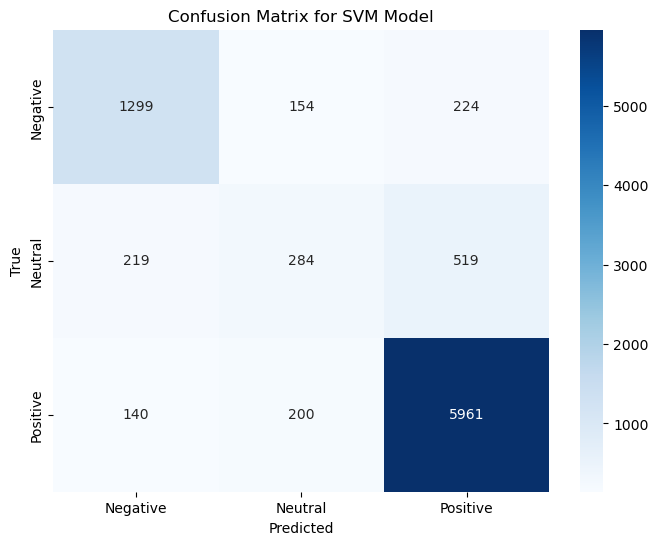

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'y_test' are the true labels and 'y_pred' are the predictions made by your model
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix with Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for SVM Model')
plt.show()


# 4. SVM model using Count Vectors for Unigram+Bigram

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Classification Report (Test Data):
              precision    recall  f1-score   support

    Negative       0.65      0.72      0.68      1677
     Neutral       0.24      0.32      0.28      1022
    Positive       0.89      0.82      0.86      6301

    accuracy                           0.75      9000
   macro avg       0.60      0.62      0.61      9000
weighted avg       0.77      0.75      0.76      9000


Confusion Matrix (Test Data):
[[1206  265  206]
 [ 264  322  436]
 [ 378  729 5194]]

--- Model: SVM with Count Vectors (Unigram + Bigram) ---
Train Time: 92.85 seconds

Training Data Check:
F1 Score (Positive): 1.0000
F1 Score (Negative): 0.8779
Accuracy: 0.9148
AUC Scores: {'Negative': 0.9794174896290428, 'Neutral': 0.9789882991904041, 'Positive': 1.0}

Testing Data Check:
F1 Score (Positive): 0.8559
F1 Score (Negative): 0.6843
Accuracy: 0.7469
AUC Scores: {'Negative': 0.8710908793175878, 'Neutral': 0.6056183614528996, 'Positive': 0.892604542560715}


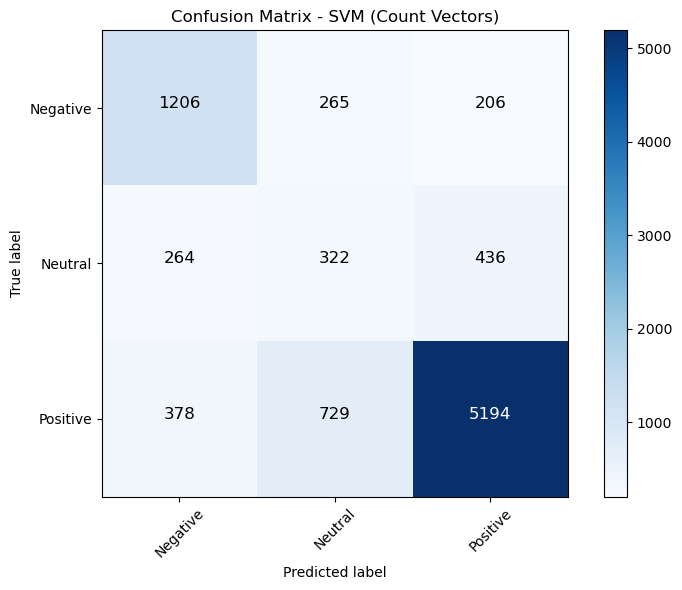

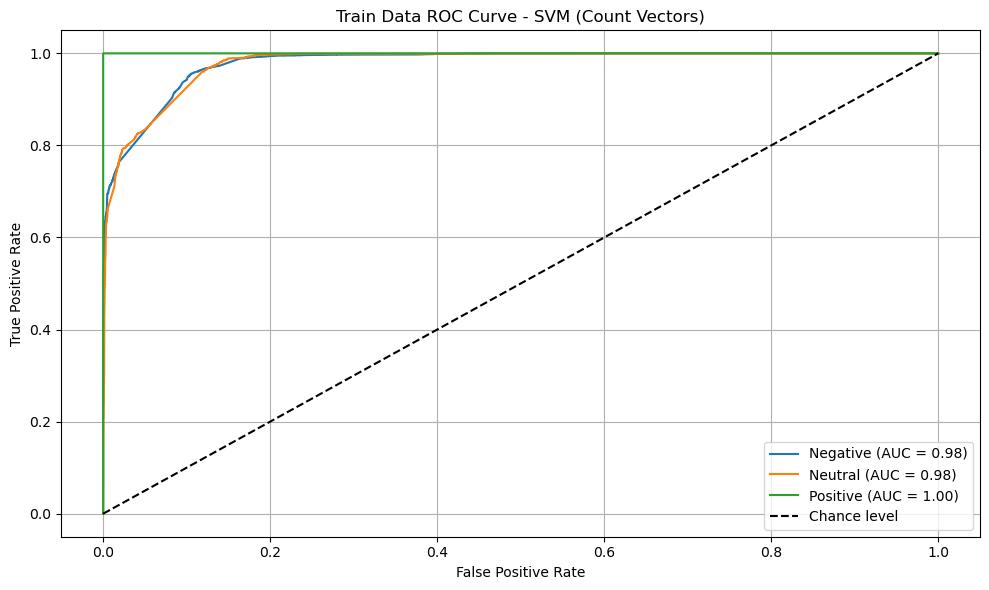

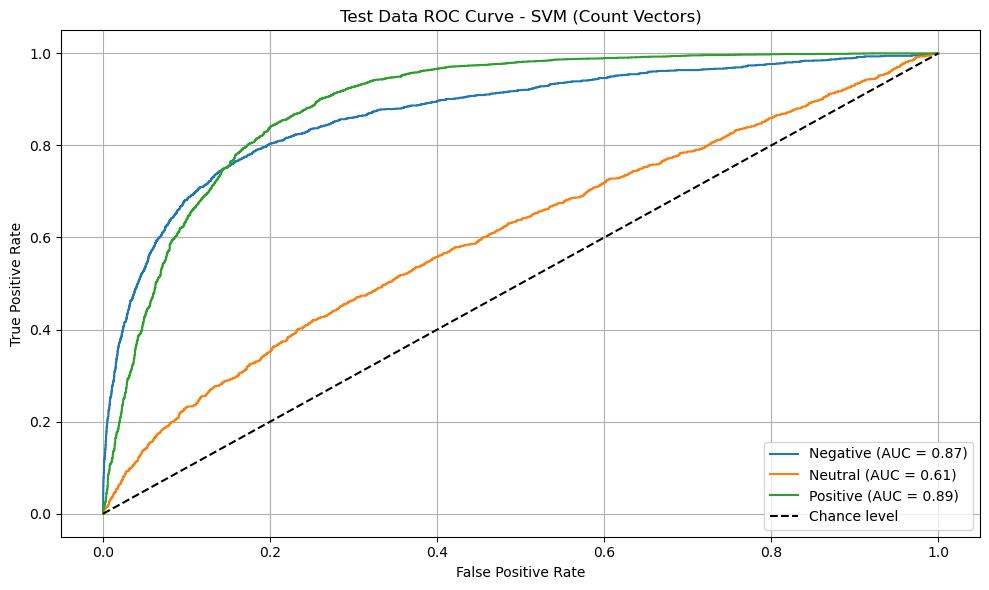

In [20]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
import time

# Assuming you have X_train, X_test, y_train, and y_test defined

# Feature Engineering with Count Vectors (Unigram + Bigram)
count_vect = CountVectorizer(ngram_range=(1, 2))  # Unigram + Bigram
X_train_cv = count_vect.fit_transform(X_train)
X_test_cv = count_vect.transform(X_test)

# Apply SMOTE (Oversampling) to handle class imbalance in the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_cv, y_train)

# Define and Train the SVM Model
svc = LinearSVC()
start_time = time.time()
svc.fit(X_train_resampled, y_train_resampled)
train_time = time.time() - start_time

# Predictions on Test Data
y_pred = svc.predict(X_test_cv)
y_pred_prob = svc.decision_function(X_test_cv)  # Get decision function scores for ROC curve

# Predictions on Train Data
y_train_pred = svc.predict(X_train_resampled)
y_train_pred_prob = svc.decision_function(X_train_resampled)

# Binarize labels for AUC calculation (on resampled training data)
y_train_binarized = label_binarize(y_train_resampled, classes=np.unique(y_train))
y_test_binarized = label_binarize(y_test, classes=np.unique(y_train))

# AUC Scores (for both test and train data)
train_auc_scores = {
    label: roc_auc_score(y_train_binarized[:, i], y_train_pred_prob[:, i])
    for i, label in enumerate(np.unique(y_train))
}

test_auc_scores = {
    label: roc_auc_score(y_test_binarized[:, i], y_pred_prob[:, i])
    for i, label in enumerate(np.unique(y_train))
}

# Classification Report (Test Data)
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_pred))

# Confusion Matrix (Test Data)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Test Data):")
print(conf_matrix)

# Training Data Metrics
train_report = classification_report(y_train_resampled, y_train_pred, output_dict=True)
f1_train_positive = train_report['Positive']['f1-score']
f1_train_negative = train_report['Negative']['f1-score']
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)

# Testing Data Metrics
f1_test_positive = classification_report(y_test, y_pred, output_dict=True)['Positive']['f1-score']
f1_test_negative = classification_report(y_test, y_pred, output_dict=True)['Negative']['f1-score']
test_accuracy = accuracy_score(y_test, y_pred)

# Output Results
print("\n--- Model: SVM with Count Vectors (Unigram + Bigram) ---")
print(f"Train Time: {train_time:.2f} seconds")

print("\nTraining Data Check:")
print(f"F1 Score (Positive): {f1_train_positive:.4f}")
print(f"F1 Score (Negative): {f1_train_negative:.4f}")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"AUC Scores: {train_auc_scores}")

print("\nTesting Data Check:")
print(f"F1 Score (Positive): {f1_test_positive:.4f}")
print(f"F1 Score (Negative): {f1_test_negative:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"AUC Scores: {test_auc_scores}")

# Plotting Confusion Matrix for Test Data
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM (Count Vectors)")
plt.colorbar()
tick_marks = np.arange(len(conf_matrix))
plt.xticks(tick_marks, np.unique(y_test), rotation=45)
plt.yticks(tick_marks, np.unique(y_test))

# Add labels to the confusion matrix
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j]), fontsize=12,
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Plot ROC Curve for both Train and Test Data
def plot_roc_curve(y_true, y_pred_prob, classes, title="ROC Curve"):
    """
    This function plots the ROC curve for each class.
    """
    plt.figure(figsize=(10, 6))
    
    # Binarize the labels for multi-class AUC
    y_true_bin = label_binarize(y_true, classes=classes)
    
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")
    
    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.tight_layout()
    plt.show()

# Plot ROC for Train Data
plot_roc_curve(y_train_resampled, y_train_pred_prob, np.unique(y_train), title="Train Data ROC Curve - SVM (Count Vectors)")

# Plot ROC for Test Data
plot_roc_curve(y_test, y_pred_prob, np.unique(y_train), title="Test Data ROC Curve - SVM (Count Vectors)")
